# Backtest with VIX + US Filter

Extends `05_custom_backtest.ipynb` by adding two skip filters:

| Filter | Rule | Rationale |
|--------|------|----------|
| **India VIX** | Skip day `t` if VIX close on day `t-1` > threshold | High fear = overnight gaps unpredictable |
| **US S&P 500** | Skip day `t` if S&P 500 return on day `t-1` < 0 | Global risk-off = negative overnight gap more likely |

Both filters use **only information available before entry at 3:20 PM** — no lookahead.

Results are compared four ways:
- Unfiltered (same as notebook 05)
- VIX filter only
- US filter only  
- Both filters combined

## Set your dates and filter thresholds

In [28]:
START_DATE = '2020-01-01'   # Extended to 2019 (earliest reliable constituent data)
END_DATE   = '2026-04-07'

VIX_THRESHOLD = 20.0   # skip day t if India VIX on t-1 was above this
US_FILTER     = True   # skip day t if S&P 500 return on t-1 was negative


## Setup

In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

LOOKBACK = 20
TOP_N    = 10
COST     = 0.0015

print('Ready.')

Ready.


## Point-in-Time NIFTY 50 Constituents

Identical to notebook 05 — full change history embedded.

In [30]:
# ── Baseline: NIFTY 50 composition as of 2019-01-01 ───────────────────────────
# Derived by reversing the 2021-04-01 composition through verified events:
#   Reverse Mar 2021: -TATACONSUM  +GAIL
#   Reverse Sep 2020: -SBILIFE     +ZEEL
#   Reverse Jul 2020: -HDFCLIFE    +VEDL
#   Reverse Mar 2020: -SHREECEM    +YESBANK
#   Reverse Sep 2019: -NESTLEIND   +IBULLHSGFIN
#   Reverse Mar 2019: -BRITANNIA   +HINDPETRO
# Result: 50 stocks verified.
# Note: Pre-2019 (2017-2018) events have unverifiable data so 2017 start is not supported.
BASELINE_DATE = pd.Timestamp('2019-01-01')
BASELINE_COMPOSITION = [
    'ADANIPORTS', 'ASIANPAINT',  'AXISBANK',   'BAJAJ-AUTO',  'BAJFINANCE',
    'BAJAJFINSV', 'BHARTIARTL',  'BPCL',        'CIPLA',       'COALINDIA',
    'DIVISLAB',   'DRREDDY',     'EICHERMOT',   'GAIL',        'GRASIM',
    'HCLTECH',    'HDFCBANK',    'HDFC',        'HEROMOTOCO',  'HINDALCO',
    'HINDPETRO',  'HINDUNILVR',  'IBULLHSGFIN', 'ICICIBANK',   'INDUSINDBK',
    'INFY',       'IOC',         'ITC',         'JSWSTEEL',    'KOTAKBANK',
    'LT',         'M&M',         'MARUTI',      'NTPC',        'ONGC',
    'POWERGRID',  'RELIANCE',    'SBIN',        'SUNPHARMA',   'TCS',
    'TATAMOTORS', 'TATASTEEL',   'TECHM',       'TITAN',       'UPL',
    'ULTRACEMCO', 'VEDL',        'WIPRO',       'YESBANK',     'ZEEL',
]  # 50 stocks  (TATAMOTORS and HDFC will be 404 on yfinance — excluded gracefully)

# ── Rebalancing events: 2019-01-01 onwards ───────────────────────────────────
CHANGE_EVENTS = [
    # 2019
    ('2019-03-29', ['BRITANNIA'],                       ['HINDPETRO']),
    ('2019-09-27', ['NESTLEIND'],                       ['IBULLHSGFIN']),
    # 2020
    ('2020-03-19', ['SHREECEM'],                        ['YESBANK']),
    ('2020-07-31', ['HDFCLIFE'],                        ['VEDL']),
    ('2020-09-25', ['SBILIFE'],                         ['ZEEL']),
    # 2021
    ('2021-03-31', ['TATACONSUM'],                      ['GAIL']),
    # 2022
    ('2022-03-31', ['APOLLOHOSP'],                      ['IOC']),
    ('2022-09-30', ['ADANIENT'],                        ['SHREECEM']),
    # 2023
    ('2023-07-13', ['LTIM'],                            ['HDFC']),
    # 2024
    ('2024-03-28', ['SHRIRAMFIN'],                      ['UPL']),
    ('2024-09-30', ['BEL', 'TRENT'],                    ['DIVISLAB', 'LTIM']),
    # 2025
    ('2025-03-28', ['JIOFIN'],                          ['BPCL']),
    ('2025-09-29', ['ETERNAL', 'INDIGO', 'MAXHEALTH'],  ['BRITANNIA', 'HEROMOTOCO', 'INDUSINDBK']),
    ('2025-10-01', ['TMPV'],                            ['TATAMOTORS']),
]

# ── yfinance ticker map ───────────────────────────────────────────────────────
YF_TICKER_MAP = {
    'HDFC':       'HDFC',        # merged Jul 2023 — 404 on yfinance
    'TATAMOTORS': 'TATAMOTORS',  # demerged Oct 2025 — 404 on yfinance
    'IBULLHSGFIN':'IBULLHSGFIN', # crisis/delisted — likely 404
    'LTIM':       'LTIM',
    'ETERNAL':    'ETERNAL',
    'BAJAJ-AUTO': 'BAJAJ-AUTO',
    'M&M':        'M%26M',
    'VEDL':       'VEDL',        # Vedanta — should work
    'YESBANK':    'YESBANK',     # still listed — should work (heavy losses 2020)
    'HINDPETRO':  'HINDPETRO',   # HPCL — should work
    'GAIL':       'GAIL',        # should work
}

# ── Point-in-time functions ───────────────────────────────────────────────────
def get_constituents_on_date(dt):
    dt = pd.Timestamp(dt)
    comp = set(BASELINE_COMPOSITION)
    for date_str, added, removed in CHANGE_EVENTS:
        if dt >= pd.Timestamp(date_str):
            comp.update(added)
            comp.difference_update(removed)
    return comp

def get_full_universe(start, end):
    universe = set(BASELINE_COMPOSITION)
    for date_str, added, removed in CHANGE_EVENTS:
        if pd.Timestamp(date_str) <= pd.Timestamp(end):
            universe.update(added)
        if pd.Timestamp(date_str) < pd.Timestamp(start):
            universe.difference_update(removed)
    return sorted(universe)

def to_yf(sym):
    return YF_TICKER_MAP.get(sym, sym) + '.NS'

def resolve_col(sym, available_cols):
    if sym in available_cols:
        return sym
    fallback = {'M&M': 'M%26M'}
    return fallback.get(sym, sym)

# ── Sanity check ──
comp_jan19 = get_constituents_on_date('2019-01-01')
comp_jan22 = get_constituents_on_date('2022-01-01')
comp_apr26 = get_constituents_on_date('2026-04-07')

assert len(comp_jan19) == 50, f"Expected 50, got {len(comp_jan19)}"
assert len(comp_jan22) == 50, f"Expected 50, got {len(comp_jan22)}"
assert len(comp_apr26) == 50, f"Expected 50, got {len(comp_apr26)}"
print(f'Constituents on 2019-01-01: {len(comp_jan19)} stocks  (TATAMOTORS and HDFC present, but will be 404 on yfinance)')
print(f'Constituents on 2022-01-01: {len(comp_jan22)} stocks')
print(f'Constituents on 2026-04-07: {len(comp_apr26)} stocks')
print()
universe = get_full_universe(START_DATE, END_DATE)
YF_TICKERS = sorted(set(to_yf(s) for s in universe))
YF_TO_NSE  = {to_yf(s): s for s in universe}
print(f'Full universe for {START_DATE} to {END_DATE}: {len(universe)} distinct stocks ({len(YF_TICKERS)} unique yfinance tickers)')


Constituents on 2019-01-01: 50 stocks  (TATAMOTORS and HDFC present, but will be 404 on yfinance)
Constituents on 2022-01-01: 50 stocks
Constituents on 2026-04-07: 50 stocks

Full universe for 2020-01-01 to 2026-04-07: 65 distinct stocks (65 unique yfinance tickers)


## Step 1 — Fetch Stock OHLC, India VIX, and S&P 500

In [31]:
fetch_start = (pd.Timestamp(START_DATE) - pd.Timedelta(days=60)).strftime('%Y-%m-%d')
# Extra buffer: VIX/GSPC need a few more days before start for the first filter check

print(f'Fetching {len(YF_TICKERS)} stock tickers from {fetch_start} to {END_DATE}...')
raw = yf.download(YF_TICKERS, start=fetch_start, end=END_DATE, progress=True, auto_adjust=True)

open_raw  = raw['Open'].copy()
close_raw = raw['Close'].copy()
open_raw.columns  = [YF_TO_NSE.get(c, c.replace('.NS','')) for c in open_raw.columns]
close_raw.columns = [YF_TO_NSE.get(c, c.replace('.NS','')) for c in close_raw.columns]

print(f'\nFetching India VIX (^INDIAVIX)...')
vix_raw = yf.download('^INDIAVIX', start=fetch_start, end=END_DATE, progress=False)['Close'].squeeze().dropna()

print(f'Fetching S&P 500 (^GSPC)...')
sp_raw  = yf.download('^GSPC',     start=fetch_start, end=END_DATE, progress=False)['Close'].squeeze().dropna()

# S&P 500 daily return
sp_ret = sp_raw.pct_change().dropna()

# Coverage check
coverage = close_raw.notna().mean()
good = coverage[coverage > 0.1].index.tolist()
poor = coverage[coverage <= 0.1].index.tolist()

print(f'\nStocks with data: {len(good)}')
if poor: print(f'Unavailable (404): {poor}')
print(f'VIX data:   {vix_raw.index[0].date()} to {vix_raw.index[-1].date()}  ({len(vix_raw)} sessions)')
print(f'S&P 500:    {sp_ret.index[0].date()} to {sp_ret.index[-1].date()}  ({len(sp_ret)} sessions)')

Fetching 65 stock tickers from 2019-11-02 to 2026-04-07...


[***********           23%                       ]  15 of 65 completed$HDFC.NS: possibly delisted; no timezone found
[********************  42%                       ]  27 of 65 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found
[*********************100%***********************]  65 of 65 completed

2 Failed downloads:
['HDFC.NS', 'TATAMOTORS.NS']: possibly delisted; no timezone found



Fetching India VIX (^INDIAVIX)...
Fetching S&P 500 (^GSPC)...

Stocks with data: 62
Unavailable (404): ['HDFC', 'TATAMOTORS', 'TMPV']
VIX data:   2019-11-04 to 2026-04-06  (1571 sessions)
S&P 500:    2019-11-05 to 2026-04-06  (1611 sessions)


## Step 2 — Compute Overnight Returns and Scores

In [32]:
overnight_df = open_raw / close_raw.shift(1) - 1
overnight_df = overnight_df.iloc[1:]
scores_df    = overnight_df.rolling(window=LOOKBACK, min_periods=LOOKBACK).mean()

first_score_date = scores_df.dropna(how='all').index[0]
eff_start = max(pd.Timestamp(START_DATE), first_score_date)
eff_end   = min(pd.Timestamp(END_DATE),   overnight_df.index[-1])
n_sessions = ((overnight_df.index >= eff_start) & (overnight_df.index <= eff_end)).sum()

print(f'Effective backtest: {eff_start.date()} to {eff_end.date()} ({n_sessions} sessions)')

Effective backtest: 2020-01-01 to 2026-04-06 (1550 sessions)


## Step 3 — Build Filter Series

For each trading day `t`, determine whether each filter passes.
Filters are checked using data from `t-1` only (no lookahead).

In [33]:
test_idx = overnight_df.index[(overnight_df.index >= eff_start) & (overnight_df.index <= eff_end)]

vix_pass = {}   # True = VIX was OK on t-1 (below threshold)
us_pass  = {}   # True = S&P 500 was non-negative on t-1

vix_values = {}  # store actual VIX value for reporting
us_values  = {}  # store actual S&P 500 return for reporting

for dt in test_idx:
    # ── VIX filter ──
    prev_vix = vix_raw[vix_raw.index < dt]
    if prev_vix.empty:
        vix_pass[dt] = True   # no data = pass (don't skip)
        vix_values[dt] = float('nan')
    else:
        v = float(prev_vix.iloc[-1])
        vix_pass[dt]   = v <= VIX_THRESHOLD
        vix_values[dt] = v

    # ── US S&P 500 filter ──
    # US and India are in different time zones.
    # The S&P 500 closes at ~1:30 AM IST the same calendar night.
    # For a 3:20 PM IST entry on date t (India), the relevant US session
    # is the one that closed on the same calendar date t in IST
    # (i.e. US trading on t-1 US date = closes early morning of t IST).
    # Approximation: use the most recent S&P 500 return available before dt.
    prev_sp = sp_ret[sp_ret.index < dt]
    if prev_sp.empty:
        us_pass[dt] = True
        us_values[dt] = float('nan')
    else:
        r = float(prev_sp.iloc[-1])
        us_pass[dt]   = r >= 0
        us_values[dt] = r

vix_pass_s = pd.Series(vix_pass)
us_pass_s  = pd.Series(us_pass)
both_pass  = vix_pass_s & us_pass_s

print(f'Total sessions:              {len(test_idx)}')
print(f'Pass VIX filter (VIX<={VIX_THRESHOLD}):   {vix_pass_s.sum()}  (skip {(~vix_pass_s).sum()} days)')
print(f'Pass US filter (SP500>=0):   {us_pass_s.sum()}  (skip {(~us_pass_s).sum()} days)')
print(f'Pass BOTH filters:           {both_pass.sum()}  (skip {(~both_pass).sum()} days)')
print()
print(f'VIX skip days: {(~vix_pass_s).mean():.1%} of sessions')
print(f'US  skip days: {(~us_pass_s).mean():.1%} of sessions')
print(f'Combined skip: {(~both_pass).mean():.1%} of sessions')

Total sessions:              1550
Pass VIX filter (VIX<=20.0):   1157  (skip 393 days)
Pass US filter (SP500>=0):   841  (skip 709 days)
Pass BOTH filters:           624  (skip 926 days)

VIX skip days: 25.4% of sessions
US  skip days: 45.7% of sessions
Combined skip: 59.7% of sessions


## Step 4 — Run All Four Variants

In [34]:
def run_top10(filter_mask=None, label='Top-10'):
    """
    filter_mask: pd.Series of bool indexed by test dates.
                 If None, trade every day.
                 If False on a date, that session returns 0 (capital sits idle).
    """
    available_cols = set(overnight_df.columns)
    out = {}
    for dt in test_idx:
        # Apply filter
        if filter_mask is not None and not filter_mask.get(dt, True):
            out[dt] = 0.0   # sit out — no return, no cost
            continue

        prev = scores_df.index[scores_df.index < dt]
        if prev.empty: continue
        score_row = scores_df.loc[prev[-1]]

        pit_syms = get_constituents_on_date(dt)
        pit_cols = set()
        for sym in pit_syms:
            col = resolve_col(sym, available_cols)
            if col in available_cols:
                pit_cols.add(col)

        eligible = list(pit_cols & set(score_row.dropna().index) & set(overnight_df.loc[dt].dropna().index))
        if len(eligible) < TOP_N: continue

        picks = score_row[eligible].nlargest(TOP_N).index
        out[dt] = overnight_df.loc[dt, picks].mean() - COST

    return pd.Series(out, name=label)


print('Running 4 variants...')
ret_none = run_top10(filter_mask=None,       label='No filter')
ret_vix  = run_top10(filter_mask=vix_pass_s, label=f'VIX<={VIX_THRESHOLD} only')
ret_us   = run_top10(filter_mask=us_pass_s,  label='US>=0 only')
ret_both = run_top10(filter_mask=both_pass,  label='VIX + US (both)')

print(f'Done.')
print(f'  No filter:    {(ret_none != 0).sum()} active sessions')
print(f'  VIX only:     {(ret_vix  != 0).sum()} active sessions')
print(f'  US only:      {(ret_us   != 0).sum()} active sessions')
print(f'  Both filters: {(ret_both != 0).sum()} active sessions')

Running 4 variants...
Done.
  No filter:    1550 active sessions
  VIX only:     1157 active sessions
  US only:      841 active sessions
  Both filters: 624 active sessions


## Results — Side-by-Side Comparison

In [35]:
def summarise(s, label=None):
    # Use only non-zero sessions for performance metrics (zeros = idle days)
    active = s[s != 0].dropna()
    all_s  = s.dropna()
    if len(active) == 0:
        print(f'  {label or s.name}: No active sessions.')
        return {}

    label = label or s.name
    n_cal   = (all_s.index[-1] - all_s.index[0]).days
    # Total return: compound all sessions including idle (0-return) days
    total   = float((1 + all_s).prod() - 1)
    ann     = (1 + total) ** (365.25 / max(n_cal, 1)) - 1 if n_cal >= 20 else float('nan')
    # Sharpe on active sessions only
    sharpe  = active.mean() / active.std() * np.sqrt(250) if active.std() > 0 else float('nan')
    cum     = (1 + all_s).cumprod()
    mdd     = float((cum / cum.cummax() - 1).min())
    wr      = float((active > 0).mean())

    print(f'  Label:          {label}')
    print(f'  Active sessions:{len(active)} / {len(all_s)}')
    print(f'  Total return:   {total:+.2%}')
    if not np.isnan(ann):   print(f'  XIRR (ann.):    {ann:+.2%}')
    if not np.isnan(sharpe):print(f'  Sharpe ratio:   {sharpe:.2f}  (on active sessions)')
    print(f'  Max drawdown:   {mdd:.2%}')
    print(f'  Win rate:       {wr:.1%}  (active sessions only)')
    print(f'  Rs 2L ->        Rs {200_000*(1+total):>9,.0f}')
    print()
    return {'Label': label, 'Active': len(active), 'Total': f'{total:+.2%}',
            'XIRR': f'{ann:+.2%}', 'Sharpe': f'{sharpe:.2f}',
            'Max DD': f'{mdd:.2%}', 'Win rate': f'{wr:.1%}',
            'Rs 2L': f'{200_000*(1+total):,.0f}'}

rows = []
for s in [ret_none, ret_vix, ret_us, ret_both]:
    print('─' * 50)
    r = summarise(s)
    if r: rows.append(r)

print('=' * 70)
print('SUMMARY TABLE')
print('=' * 70)
display(pd.DataFrame(rows).set_index('Label'))

──────────────────────────────────────────────────
  Label:          No filter
  Active sessions:1550 / 1550
  Total return:   +146.14%
  XIRR (ann.):    +15.47%
  Sharpe ratio:   1.28  (on active sessions)
  Max drawdown:   -24.89%
  Win rate:       59.5%  (active sessions only)
  Rs 2L ->        Rs   492,280

──────────────────────────────────────────────────
  Label:          VIX<=20.0 only
  Active sessions:1157 / 1550
  Total return:   +26.73%
  XIRR (ann.):    +3.86%
  Sharpe ratio:   0.63  (on active sessions)
  Max drawdown:   -23.07%
  Win rate:       57.8%  (active sessions only)
  Rs 2L ->        Rs   253,466

──────────────────────────────────────────────────
  Label:          US>=0 only
  Active sessions:841 / 1550
  Total return:   +937.27%
  XIRR (ann.):    +45.29%
  Sharpe ratio:   7.38  (on active sessions)
  Max drawdown:   -4.62%
  Win rate:       76.2%  (active sessions only)
  Rs 2L ->        Rs 2,074,547

──────────────────────────────────────────────────
  Label:

,Active,Total,XIRR,Sharpe,Max DD,Win rate,Rs 2L
Label,,,,,,,
No filter,1550,+146.14%,+15.47%,1.28,-24.89%,59.5%,"492,280"
VIX<=20.0 only,1157,+26.73%,+3.86%,0.63,-23.07%,57.8%,"253,466"
US>=0 only,841,+937.27%,+45.29%,7.38,-4.62%,76.2%,"2,074,547"
VIX + US (both),624,+224.89%,+20.71%,6.58,-3.70%,74.4%,"649,780"


## Filter Diagnostics — What Days Were Skipped?

In [36]:
# Build a diagnostic frame: for every skipped day, what were the returns?
# This tells us whether the filter is genuinely avoiding bad days.

diag = pd.DataFrame({
    'VIX_prev':    pd.Series(vix_values),
    'US_ret_prev': pd.Series(us_values),
    'vix_pass':    vix_pass_s,
    'us_pass':     us_pass_s,
    'ret_none':    ret_none,
}).loc[test_idx]

# VIX skip days: were the overnight returns actually worse?
vix_skip_ret  = diag.loc[~diag['vix_pass'], 'ret_none']
vix_trade_ret = diag.loc[ diag['vix_pass'], 'ret_none']
us_skip_ret   = diag.loc[~diag['us_pass'],  'ret_none']
us_trade_ret  = diag.loc[ diag['us_pass'],  'ret_none']

print('=== VIX Filter Analysis ===')
print(f'Days skipped (VIX > {VIX_THRESHOLD}): {len(vix_skip_ret)}')
if len(vix_skip_ret) > 0:
    print(f'  Mean return on SKIPPED days:  {vix_skip_ret.mean():+.4%}')
    print(f'  Win rate on SKIPPED days:     {(vix_skip_ret > 0).mean():.1%}')
print(f'Days traded (VIX <= {VIX_THRESHOLD}): {len(vix_trade_ret)}')
print(f'  Mean return on TRADED days:   {vix_trade_ret.mean():+.4%}')
print(f'  Win rate on TRADED days:      {(vix_trade_ret > 0).mean():.1%}')
print()

print('=== US S&P 500 Filter Analysis ===')
print(f'Days skipped (S&P prev < 0): {len(us_skip_ret)}')
if len(us_skip_ret) > 0:
    print(f'  Mean return on SKIPPED days:  {us_skip_ret.mean():+.4%}')
    print(f'  Win rate on SKIPPED days:     {(us_skip_ret > 0).mean():.1%}')
print(f'Days traded (S&P prev >= 0): {len(us_trade_ret)}')
print(f'  Mean return on TRADED days:   {us_trade_ret.mean():+.4%}')
print(f'  Win rate on TRADED days:      {(us_trade_ret > 0).mean():.1%}')
print()

# Key question: are skipped days statistically worse?
if len(vix_skip_ret) > 5 and len(vix_trade_ret) > 5:
    from scipy import stats
    t_vix, p_vix = stats.ttest_ind(vix_trade_ret.dropna(), vix_skip_ret.dropna())
    print(f'VIX filter: t-test p-value = {p_vix:.3f}  ', end='')
    print('(significant at 5%)' if p_vix < 0.05 else '(NOT significant — filter may be noise)')

if len(us_skip_ret) > 5 and len(us_trade_ret) > 5:
    t_us, p_us = stats.ttest_ind(us_trade_ret.dropna(), us_skip_ret.dropna())
    print(f'US  filter: t-test p-value = {p_us:.3f}  ', end='')
    print('(significant at 5%)' if p_us < 0.05 else '(NOT significant — filter may be noise)')

=== VIX Filter Analysis ===
Days skipped (VIX > 20.0): 393
  Mean return on SKIPPED days:  +0.1757%
  Win rate on SKIPPED days:     64.4%
Days traded (VIX <= 20.0): 1157
  Mean return on TRADED days:   +0.0220%
  Win rate on TRADED days:      57.8%

=== US S&P 500 Filter Analysis ===
Days skipped (S&P prev < 0): 709
  Mean return on SKIPPED days:  -0.1992%
  Win rate on SKIPPED days:     39.6%
Days traded (S&P prev >= 0): 841
  Mean return on TRADED days:   +0.2803%
  Win rate on TRADED days:      76.2%

VIX filter: t-test p-value = 0.000  (significant at 5%)
US  filter: t-test p-value = 0.000  (significant at 5%)


## VIX Threshold Sensitivity

What if we used VIX 15, 18, 20, 22, 25 as the threshold? Shows how sensitive the result is.

In [37]:
thresholds = [15, 18, 20, 22, 25, 30]
sens_rows = []

for thresh in thresholds:
    vix_mask = {dt: float(vix_raw[vix_raw.index < dt].iloc[-1]) <= thresh
                if not vix_raw[vix_raw.index < dt].empty else True
                for dt in test_idx}
    vix_mask_s = pd.Series(vix_mask)
    s = run_top10(filter_mask=vix_mask_s, label=f'VIX<={thresh}')
    active = s[s != 0].dropna()
    total  = float((1 + s.dropna()).prod() - 1)
    n_cal  = (s.index[-1] - s.index[0]).days
    ann    = (1 + total) ** (365.25 / max(n_cal, 1)) - 1
    sharpe = active.mean() / active.std() * np.sqrt(250) if len(active) > 1 and active.std() > 0 else float('nan')
    sens_rows.append({
        'VIX threshold': thresh,
        'Active sessions': len(active),
        'Skipped sessions': len(test_idx) - len(active),
        'XIRR': f'{ann:+.2%}',
        'Sharpe': f'{sharpe:.2f}',
        'Rs 2L': f'{200_000*(1+total):,.0f}',
    })

display(pd.DataFrame(sens_rows).set_index('VIX threshold'))

,Active sessions,Skipped sessions,XIRR,Sharpe,Rs 2L
VIX threshold,,,,,
15,743,807,+1.19%,0.34,"215,337"
18,1006,544,+3.78%,0.73,"252,231"
20,1157,393,+3.86%,0.63,"253,466"
22,1299,251,+7.69%,1.04,"318,067"
25,1432,118,+11.05%,1.24,"385,426"
30,1486,64,+13.57%,1.39,"443,553"


## Charts — All Four Variants

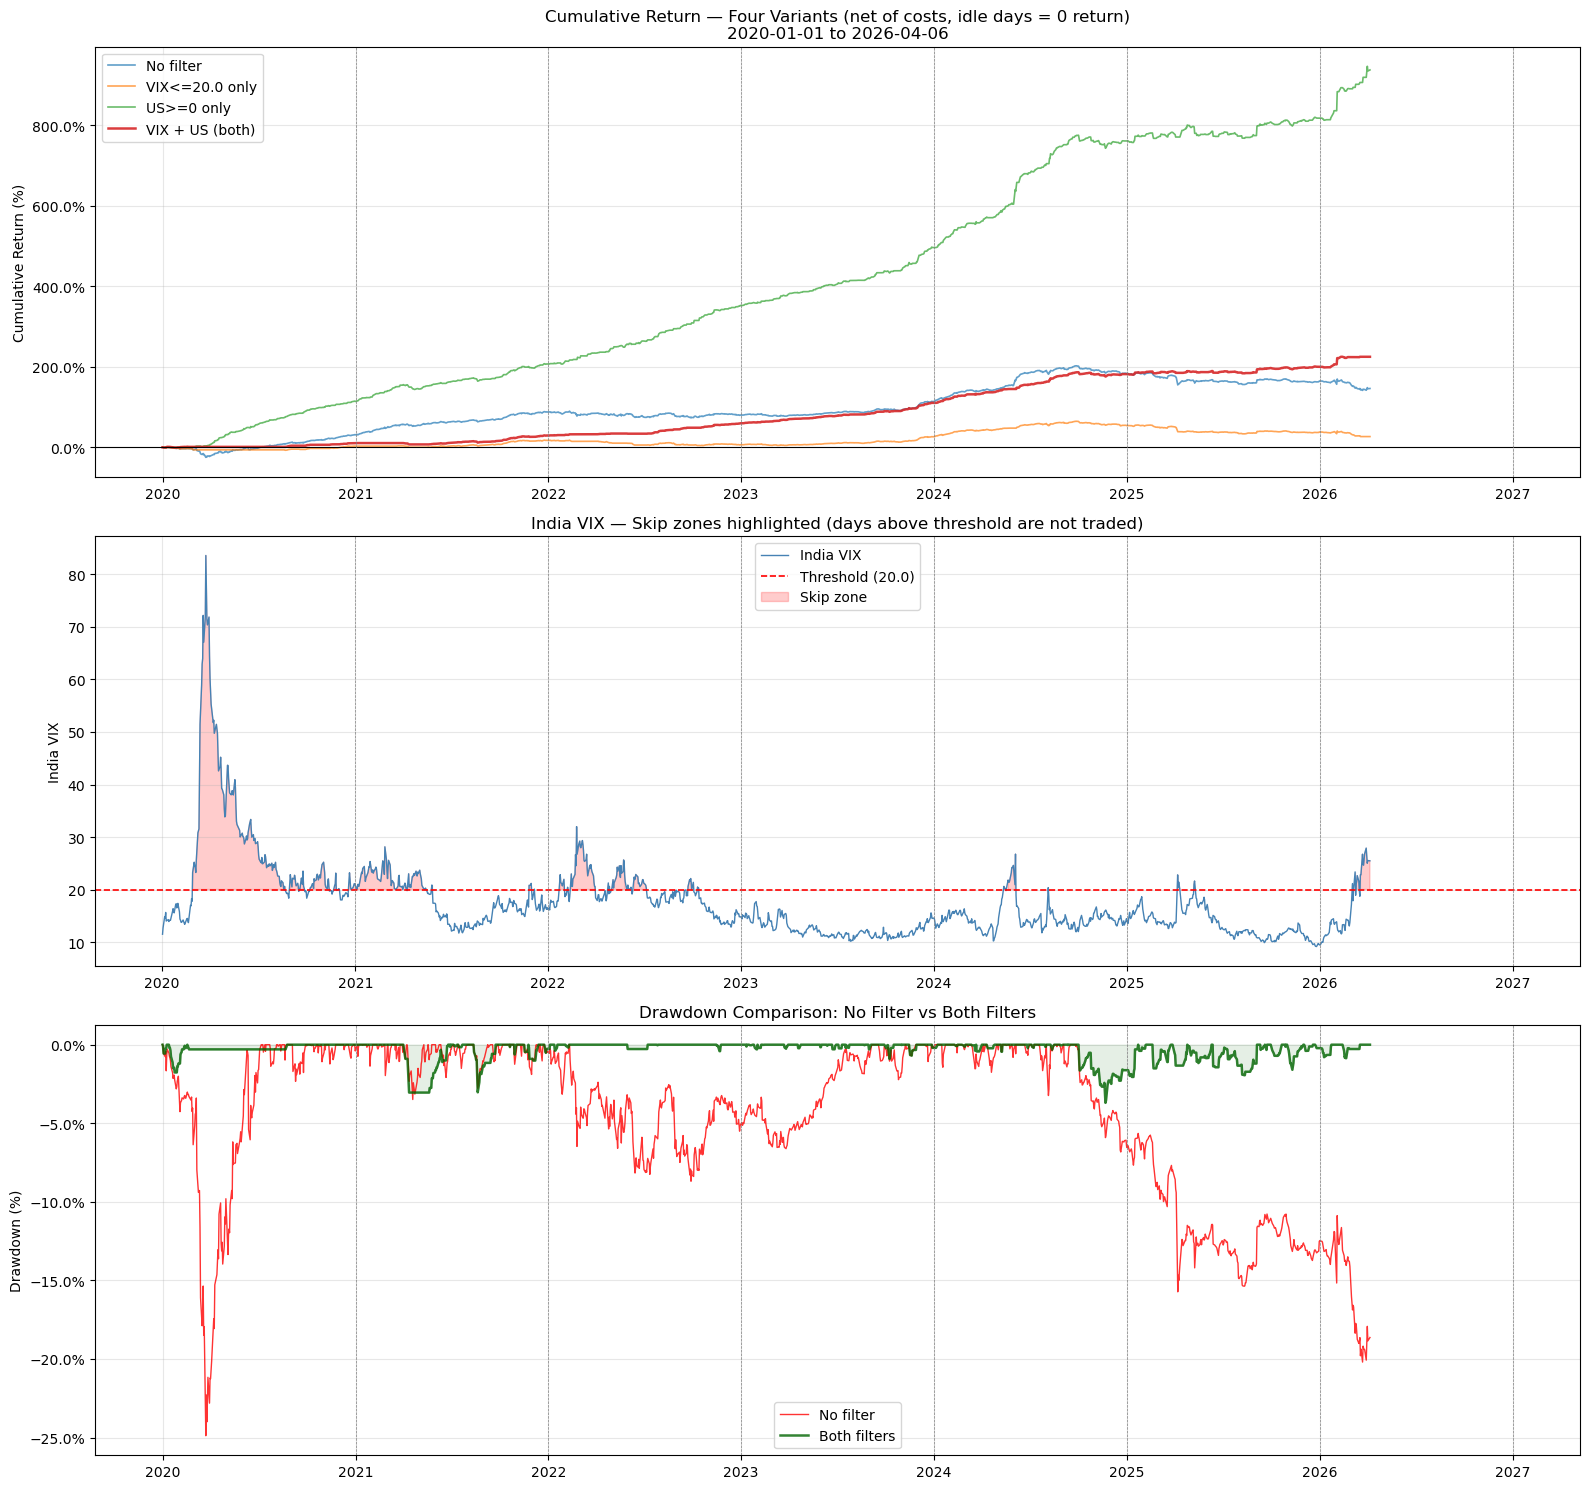

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

# ── Cumulative returns ──
ax = axes[0]
colors = ['grey', 'steelblue', 'orange', 'darkgreen']
for s, color in zip([ret_none, ret_vix, ret_us, ret_both], colors):
    cum = (1 + s.dropna()).cumprod() - 1
    ax.plot(cum.index, cum * 100, label=s.name, linewidth=1.8 if 'both' in s.name else 1.2,
            alpha=0.9 if 'both' in s.name else 0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Cumulative Return — Four Variants (net of costs, idle days = 0 return)\n{eff_start.date()} to {eff_end.date()}')
ax.set_ylabel('Cumulative Return (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.legend()
for yr in range(eff_start.year + 1, eff_end.year + 2):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')

# ── VIX over time with skip zones highlighted ──
ax = axes[1]
vix_plot = vix_raw[(vix_raw.index >= eff_start) & (vix_raw.index <= eff_end)]
ax.plot(vix_plot.index, vix_plot, color='steelblue', linewidth=1.0, label='India VIX')
ax.axhline(VIX_THRESHOLD, color='red', linewidth=1.2, linestyle='--', label=f'Threshold ({VIX_THRESHOLD})')
ax.fill_between(vix_plot.index, vix_plot, VIX_THRESHOLD,
                where=(vix_plot > VIX_THRESHOLD), color='red', alpha=0.2, label='Skip zone')
ax.set_title('India VIX — Skip zones highlighted (days above threshold are not traded)')
ax.set_ylabel('India VIX')
ax.legend()
for yr in range(eff_start.year + 1, eff_end.year + 2):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')

# ── Drawdown comparison: no filter vs both filters ──
ax = axes[2]
for s, color, lw, label in [
    (ret_none, 'red',       1.0, 'No filter'),
    (ret_both, 'darkgreen', 1.8, 'Both filters'),
]:
    cum = (1 + s.dropna()).cumprod()
    dd  = (cum / cum.cummax() - 1) * 100
    ax.plot(dd.index, dd, color=color, linewidth=lw, label=label, alpha=0.8)
ax.fill_between(dd.index, dd, 0, color='darkgreen', alpha=0.1)
ax.set_title('Drawdown Comparison: No Filter vs Both Filters')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.legend()
for yr in range(eff_start.year + 1, eff_end.year + 2):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

## Year-by-Year: No Filter vs Both Filters

In [39]:
years = sorted(ret_none.index.year.unique())
yr_rows = []

for yr in years:
    tn = ret_none[(ret_none.index.year == yr)]
    tb = ret_both[(ret_both.index.year == yr)]
    if len(tn) < 5: continue

    def ann(x):
        tot = float((1+x).prod()-1)
        return (1+tot)**(250/len(x))-1
    def mdd(x):
        c=(1+x).cumprod(); return float((c/c.cummax()-1).min())
    def wr(x): return float((x[x!=0]>0).mean())
    def active(x): return int((x!=0).sum())

    yr_rows.append({
        'Year':                yr,
        'No-filter ann.':      f'{ann(tn):+.1%}',
        'No-filter WR':        f'{wr(tn):.1%}',
        'Filtered ann.':       f'{ann(tb):+.1%}',
        'Filtered WR':         f'{wr(tb):.1%}',
        'Filtered sessions':   active(tb),
        'Skipped':             len(tb) - active(tb),
        'No-filter MaxDD':     f'{mdd(tn):.1%}',
        'Filtered MaxDD':      f'{mdd(tb):.1%}',
    })

display(pd.DataFrame(yr_rows).set_index('Year'))

,No-filter ann.,No-filter WR,Filtered ann.,Filtered WR,Filtered sessions,Skipped,No-filter MaxDD,Filtered MaxDD
Year,,,,,,,,
2020,+30.9%,64.9%,+10.5%,75.0%,44,207,-24.9%,-1.8%
2021,+43.8%,69.4%,+17.1%,76.9%,91,157,-3.5%,-3.0%
2022,-4.2%,53.6%,+23.6%,88.7%,62,186,-8.7%,-0.4%
2023,+19.1%,62.4%,+32.6%,79.9%,134,111,-3.4%,-0.9%
2024,+33.0%,63.8%,+34.5%,77.3%,132,114,-6.8%,-3.7%
2025,-6.5%,49.0%,+6.5%,60.4%,139,110,-10.7%,-1.9%
2026,-25.0%,34.9%,+36.9%,59.1%,22,41,-10.5%,-0.9%


## vs NIFTY Index Fund — After Filtering

In [40]:
nifty = yf.download('^NSEI', start=str(eff_start.date()), end=END_DATE, progress=False)['Close'].squeeze().dropna()

if len(nifty) >= 2:
    nifty_ret   = float(nifty.iloc[-1] / nifty.iloc[0] - 1)
    n_cal       = (nifty.index[-1] - nifty.index[0]).days
    nifty_xirr  = (1 + nifty_ret) ** (365.25 / max(n_cal, 1)) - 1

    print(f'Period: {nifty.index[0].date()} to {nifty.index[-1].date()}')
    print()
    print(f'  {"":<32} {"Total":>10}  {"XIRR":>10}  {"After 20% STCG":>15}')
    print(f'  {"-"*72}')

    for s, tax in [
        (ret_none, 0.20),
        (ret_vix,  0.20),
        (ret_us,   0.20),
        (ret_both, 0.20),
    ]:
        tot  = float((1 + s.dropna()).prod() - 1)
        xirr = (1 + tot) ** (365.25 / max(n_cal, 1)) - 1
        after_tax_xirr = xirr * (1 - tax)
        print(f'  {s.name:<32} {tot:>+10.2%}  {xirr:>+10.2%}  {after_tax_xirr:>+15.2%}')

    print(f'  {"-"*72}')
    nifty_after_tax = nifty_xirr * (1 - 0.10)  # LTCG 10%
    print(f'  {"NIFTY index fund":<32} {nifty_ret:>+10.2%}  {nifty_xirr:>+10.2%}  {nifty_after_tax:>+15.2%}  (10% LTCG)')
    print()
    print('  Note: STCG rate 20% applied to strategy returns (overnight trades = short-term).')
    print('  LTCG rate 10% applied to index fund (held 1+ year, above Rs 1L exemption).')

Period: 2020-01-01 to 2026-04-06

                                        Total        XIRR   After 20% STCG
  ------------------------------------------------------------------------
  No filter                          +146.14%     +15.47%          +12.38%
  VIX<=20.0 only                      +26.73%      +3.86%           +3.08%
  US>=0 only                         +937.27%     +45.29%          +36.23%
  VIX + US (both)                    +224.89%     +20.71%          +16.56%
  ------------------------------------------------------------------------
  NIFTY index fund                    +88.53%     +10.66%           +9.59%  (10% LTCG)

  Note: STCG rate 20% applied to strategy returns (overnight trades = short-term).
  LTCG rate 10% applied to index fund (held 1+ year, above Rs 1L exemption).


## Fresh Signal Filter — Drop Mondays and Post-US-Holiday Days

**Hypothesis:** On Mondays, the S&P 500 signal is 3 calendar days old (Friday's close). After a US holiday it is 2–4 days old. A stale signal should be less predictive.

Only trade when the US session closed the *immediately preceding night* (staleness = exactly 1 calendar day between the India date and the most recent US date).

In [41]:
# ── Freshness filter ──────────────────────────────────────────────────────────
# For each India trading day t, find how many calendar days ago the
# most recent S&P 500 session was.
#   staleness == 1  →  US closed Mon evening, India trades Tuesday → fresh
#   staleness == 3  →  US closed Friday, India trades Monday       → stale (Monday)
#   staleness >= 2  →  US holiday, India trades next day           → stale

fresh_pass = {}
staleness_map = {}

for dt in test_idx:
    prev_sp = sp_ret[sp_ret.index < dt]
    if prev_sp.empty:
        fresh_pass[dt]   = False   # no US data at all → skip
        staleness_map[dt] = None
    else:
        last_us_date = prev_sp.index[-1]
        staleness    = (dt - last_us_date).days
        # Fresh = US session was exactly 1 calendar day ago
        fresh_pass[dt]    = (staleness == 1)
        staleness_map[dt] = staleness

fresh_pass_s = pd.Series(fresh_pass)

# US + Fresh: S&P positive AND signal is fresh (not Monday / post-holiday)
us_and_fresh = us_pass_s & fresh_pass_s

print('=== Staleness breakdown ===')
stale_counts = pd.Series(staleness_map).value_counts().sort_index()
for days, count in stale_counts.items():
    label = 'fresh (Tue-Fri after normal US session)' if days == 1 else             'Monday (Friday US data, 3 days old)'     if days == 3 else             f'post-holiday ({days} days old)'
    print(f'  Staleness {days:>2} day(s): {count:>4} sessions  — {label}')

print()
print(f'Total sessions:             {len(test_idx)}')
print(f'Fresh signal days:          {fresh_pass_s.sum()}  (staleness == 1)')
print(f'Stale days (Mondays+hols):  {(~fresh_pass_s).sum()}')
print()
print(f'US filter only:             {us_pass_s.sum()} sessions traded')
print(f'US filter + fresh only:     {us_and_fresh.sum()} sessions traded')
print(f'  Dropped by freshness:     {us_pass_s.sum() - us_and_fresh.sum()} additional sessions skipped')

# ── Run the fresh-filtered variant ───────────────────────────────────────────
ret_us_fresh = run_top10(filter_mask=us_and_fresh, label='US>=0 + Fresh (no Mon/hol)')

# ── Compare win rates ─────────────────────────────────────────────────────────
def win_rate(s): return float((s[s != 0] > 0).mean())
def xirr(s):
    tot = float((1 + s.dropna()).prod() - 1)
    n   = (s.index[-1] - s.index[0]).days
    return (1 + tot) ** (365.25 / max(n, 1)) - 1

print()
print('=' * 65)
print(f'  {"Variant":<35} {"Sessions":>8}  {"Win rate":>9}  {"XIRR":>8}')
print('=' * 65)
for s in [ret_none, ret_us, ret_us_fresh]:
    active = int((s != 0).sum())
    print(f'  {s.name:<35} {active:>8}  {win_rate(s):>9.1%}  {xirr(s):>+8.2%}')
print('=' * 65)
print()

# ── Day-of-week breakdown on US-filter sessions ───────────────────────────────
print('=== Win rate by day of week (US filter sessions only) ===')
us_active = ret_us[ret_us != 0]
days_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday'}
for dow in range(5):
    subset = us_active[us_active.index.dayofweek == dow]
    if len(subset) == 0: continue
    wr = (subset > 0).mean()
    print(f'  {days_map[dow]:<12}: {len(subset):>4} sessions  win rate {wr:.1%}  mean ret {subset.mean():+.4%}')
print()
print('  Monday win rate tells you if the stale-signal problem is real.')


=== Staleness breakdown ===
  Staleness  1 day(s): 1190 sessions  — fresh (Tue-Fri after normal US session)
  Staleness  2 day(s):   16 sessions  — post-holiday (2 days old)
  Staleness  3 day(s):  298 sessions  — Monday (Friday US data, 3 days old)
  Staleness  4 day(s):   46 sessions  — post-holiday (4 days old)

Total sessions:             1550
Fresh signal days:          1190  (staleness == 1)
Stale days (Mondays+hols):  360

US filter only:             841 sessions traded
US filter + fresh only:     643 sessions traded
  Dropped by freshness:     198 additional sessions skipped

  Variant                             Sessions   Win rate      XIRR
  No filter                               1550      59.5%   +15.47%
  US>=0 only                               841      76.2%   +45.29%
  US>=0 + Fresh (no Mon/hol)               643      78.1%   +34.61%

=== Win rate by day of week (US filter sessions only) ===
  Monday      :  167 sessions  win rate 73.7%  mean ret +0.2835%
  Tuesday    